In [ ]:


# ================================================================
# BLOQUE 1: IMPORTS GENERALES Y CONFIGURACIÓN
# ================================================================
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, random_split
from torchvision import datasets, models, transforms
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import time, copy
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# ================================================================
# BLOQUE 2: RUTAS A DATASETS
# ================================================================

trashnet_dir = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\data_preprocessed\ResNet18\TrashNet"
taco_dir     = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\data_preprocessed\ResNet18\TACO"

output_dir = r"D:\Documentos\IPN\6to Semestre\Metodologia_de_la_investigacion\Clasificacion_residuos\Programas\ResNet\Modelos_experimentos"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ================================================================
# BLOQUE 3: FUNCIONES AUXILIARES
# ================================================================

def split_stratified(dataset, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    targets = np.array(dataset.targets)
    classes = np.unique(targets)
    
    train_idx, val_idx, test_idx = [], [], []
    for c in classes:
        c_idx = np.where(targets == c)[0]
        np.random.shuffle(c_idx)
        n_total = len(c_idx)
        n_train = int(train_ratio * n_total)
        n_val = int(val_ratio * n_total)
        
        train_idx += list(c_idx[:n_train])
        val_idx   += list(c_idx[n_train:n_train+n_val])
        test_idx  += list(c_idx[n_train+n_val:])
    
    return train_idx, val_idx, test_idx


def make_balanced_sampler(subset, full_dataset):
    targets = np.array(full_dataset.targets)
    subset_targets = targets[subset.indices]
    class_counts = Counter(subset_targets)
    weights = {cls: 1.0/count for cls, count in class_counts.items()}
    sample_weights = [weights[label] for label in subset_targets]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [4]:
# ================================================================
# BLOQUE 4: FUNCIÓN DE ENTRENAMIENTO CON HISTORIAL PARA CURVAS
# ================================================================

def train_model(model, criterion, optimizer, dataloaders, dataset_sizes,
                num_epochs=20, patience=4, save_name="modelo.pth"):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    no_improve = 0

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 50)

        for phase in ["train", "val"]:
            model.train() if phase=="train" else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=="train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase=="train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds==labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double()/dataset_sizes[phase]

            print(f"{phase.upper()} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # registrar historial
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            # early stopping
            if phase == "val":
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    no_improve = 0
                else:
                    no_improve += 1

        if no_improve >= patience:
            print("\nEARLY STOPPING activado")
            break

    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), os.path.join(output_dir, save_name))

    print(f"\nMejor ACC validación: {best_acc:.4f}")
    return model, history

In [5]:
# ================================================================
# BLOQUE 5: FUNCIÓN PARA GRAFICAR CURVAS DE APRENDIZAJE
# ================================================================

def plot_curves(history, title="Curvas de aprendizaje"):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Épocas")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Épocas")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [6]:
# ================================================================
# FUNCIÓN DE EVALUACIÓN COMPLETA
# Matriz de confusión (gráfica) + metrics por defecto en consola
# ================================================================

def evaluar_en_test(model, loader, class_names, modelo_nombre="Modelo"):
    model.eval()
    all_preds, all_labels = [], []

    # 1. Recolectar predicciones reales vs predichas
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ===========================================================
    # 2. Reporte de clasificación (texto)
    # ===========================================================
    print("\n===============================================")
    print(f"   REPORTES DE EVALUACIÓN - {modelo_nombre}")
    print("===============================================\n")

    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=3
    ))

    # ===========================================================
    # 3. Matriz de confusión (gráfica)
    # ===========================================================

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(7,6))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Matriz de Confusión - {modelo_nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta Real")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
    plt.yticks(np.arange(len(class_names)), class_names)

    # valores dentro de celdas
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # ===========================================================
    # 4. Exactitud total
    # ===========================================================
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Exactitud global en TEST ({modelo_nombre}): {acc:.4f}")

    return acc

Clases TrashNet: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Época 1/10
--------------------------------------------------
TRAIN | Loss: 1.3464 | Acc: 0.5077
VAL | Loss: 1.0767 | Acc: 0.6139

Época 2/10
--------------------------------------------------
TRAIN | Loss: 0.8901 | Acc: 0.7158
VAL | Loss: 0.8638 | Acc: 0.6997

Época 3/10
--------------------------------------------------
TRAIN | Loss: 0.7610 | Acc: 0.7490
VAL | Loss: 0.7640 | Acc: 0.7399

Época 4/10
--------------------------------------------------
TRAIN | Loss: 0.6700 | Acc: 0.7897
VAL | Loss: 0.7290 | Acc: 0.7534

Época 5/10
--------------------------------------------------
TRAIN | Loss: 0.5957 | Acc: 0.8183
VAL | Loss: 0.7133 | Acc: 0.7560

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.5840 | Acc: 0.8120
VAL | Loss: 0.6619 | Acc: 0.7694

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.5612 | Acc: 0.8155
VAL | Loss: 0.6732 | Acc: 0.7534

Époc

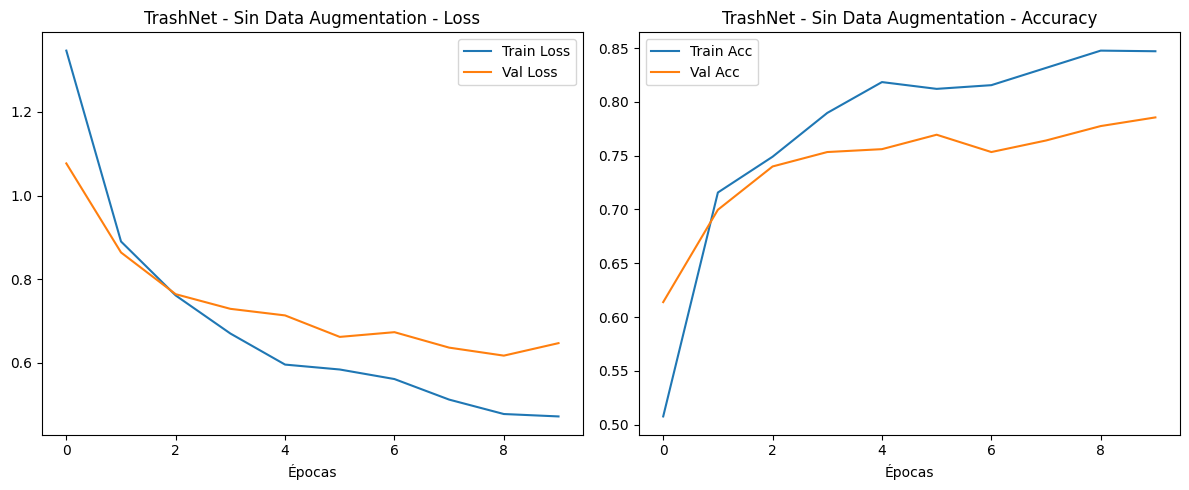

In [ ]:
# ================================================================
# BLOQUE 6: ENTRENAMIENTO TRASHNET - SIN DATA AUGMENTATION
# ================================================================

transform = transforms.ToTensor()
trashnet_full = datasets.ImageFolder(trashnet_dir, transform=transform)
print("Clases TrashNet:", trashnet_full.classes)

train_idx, val_idx, test_idx = split_stratified(trashnet_full)
train_ds = Subset(trashnet_full, train_idx)
val_ds   = Subset(trashnet_full, val_idx)
test_ds  = Subset(trashnet_full, test_idx)

sampler  = make_balanced_sampler(train_ds, trashnet_full)

batch = 32
train_loader = DataLoader(train_ds, batch_size=batch, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=batch)
test_loader  = DataLoader(test_ds, batch_size=batch)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_ds), "val": len(val_ds)}

# --- MODELO ---
model_tn = models.resnet18(weights="IMAGENET1K_V1")
for p in model_tn.parameters():
    p.requires_grad = False

model_tn.fc = nn.Linear(model_tn.fc.in_features, len(trashnet_full.classes))
model_tn = model_tn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tn.fc.parameters(), lr=1e-3)

model_tn, hist_tn = train_model(
    model_tn, criterion, optimizer,
    dataloaders, dataset_sizes,
    num_epochs=10, patience=4,
    save_name="resnet18_trashnet_pretrain.pth"
)

plot_curves(hist_tn, "TrashNet - Sin Data Augmentation")


Época 1/12
--------------------------------------------------
TRAIN | Loss: 1.3659 | Acc: 0.4900
VAL | Loss: 1.0389 | Acc: 0.6524

Época 2/12
--------------------------------------------------
TRAIN | Loss: 0.9006 | Acc: 0.7147
VAL | Loss: 0.8058 | Acc: 0.7219

Época 3/12
--------------------------------------------------
TRAIN | Loss: 0.7806 | Acc: 0.7381
VAL | Loss: 0.7107 | Acc: 0.7540

Época 4/12
--------------------------------------------------
TRAIN | Loss: 0.6713 | Acc: 0.7804
VAL | Loss: 0.6699 | Acc: 0.7727

Época 5/12
--------------------------------------------------
TRAIN | Loss: 0.6030 | Acc: 0.8125
VAL | Loss: 0.6345 | Acc: 0.7807

Época 6/12
--------------------------------------------------
TRAIN | Loss: 0.5870 | Acc: 0.8067
VAL | Loss: 0.6125 | Acc: 0.7888

Época 7/12
--------------------------------------------------
TRAIN | Loss: 0.5367 | Acc: 0.8256
VAL | Loss: 0.6012 | Acc: 0.7754

Época 8/12
--------------------------------------------------
TRAIN | Loss: 0.5122

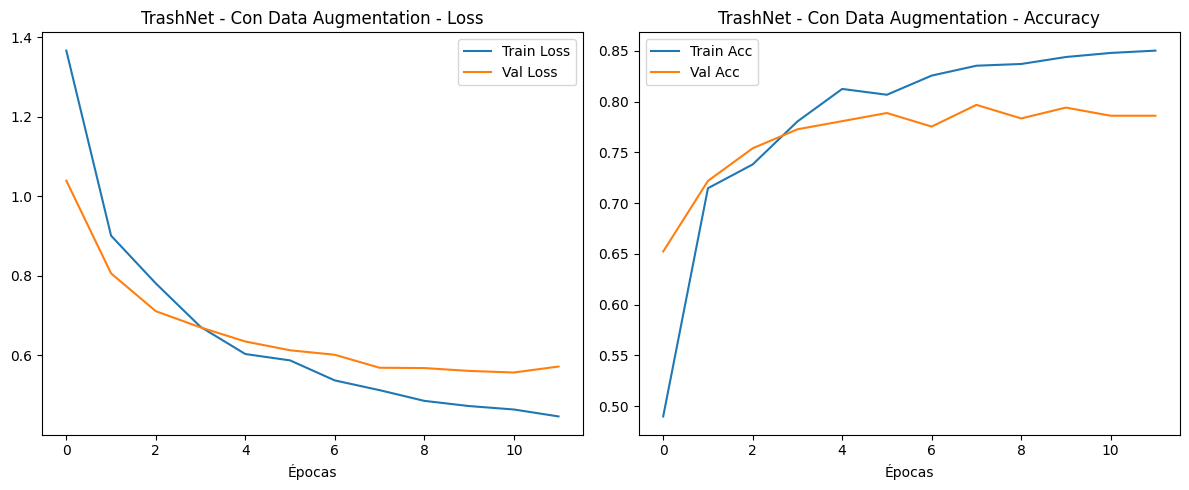

In [ ]:
# ================================================================
# BLOQUE 7: ENTRENAMIENTO TRASHNET - CON DATA AUGMENTATION
# ================================================================

train_transform_tn = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor()
])

base_transform_tn = transforms.ToTensor()

trashnet_aug_full = datasets.ImageFolder(trashnet_dir, transform=train_transform_tn)

# split reproducible
train_size = int(0.7 * len(trashnet_aug_full))
val_size   = int(0.15 * len(trashnet_aug_full))
test_size  = len(trashnet_aug_full) - train_size - val_size

torch.manual_seed(42)
train_ds_aug, val_ds_aug, test_ds_aug = random_split(
    trashnet_aug_full, [train_size, val_size, test_size]
)

# para validación y test: sin augmentación
val_ds_aug.dataset.transform  = base_transform_tn
test_ds_aug.dataset.transform = base_transform_tn

train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True)
val_loader_aug   = DataLoader(val_ds_aug, batch_size=32)
test_loader_aug  = DataLoader(test_ds_aug, batch_size=32)

dataloaders_aug = {"train": train_loader_aug, "val": val_loader_aug}
dataset_sizes_aug = {"train": len(train_ds_aug), "val": len(val_ds_aug)}

# Modelo
model_tn_aug = models.resnet18(weights="IMAGENET1K_V1")
for p in model_tn_aug.parameters():
    p.requires_grad = False

model_tn_aug.fc = nn.Linear(model_tn_aug.fc.in_features, len(trashnet_aug_full.classes))
model_tn_aug = model_tn_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tn_aug.fc.parameters(), lr=1e-3)

model_tn_aug, hist_tn_aug = train_model(
    model_tn_aug, criterion, optimizer,
    dataloaders_aug, dataset_sizes_aug,
    num_epochs=10, patience=4,
    save_name="resnet18_trashnet_aug_pretrain.pth"
)

plot_curves(hist_tn_aug, "TrashNet - Con Data Augmentation")



=== EVALUACIÓN TrashNet - SIN DA ===

   REPORTES DE EVALUACIÓN - TrashNet - Sin DA

              precision    recall  f1-score   support

   cardboard      0.962     0.820     0.885        61
       glass      0.788     0.539     0.641        76
       metal      0.657     0.742     0.697        62
       paper      0.886     0.897     0.891        87
     plastic      0.645     0.822     0.723        73
       trash      0.615     0.727     0.667        22

    accuracy                          0.764       381
   macro avg      0.759     0.758     0.751       381
weighted avg      0.780     0.764     0.763       381



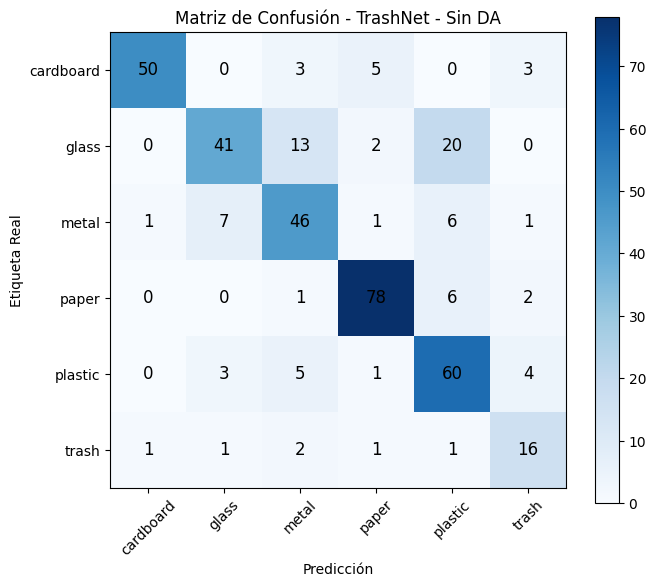

Exactitud global en TEST (TrashNet - Sin DA): 0.7638

=== EVALUACIÓN TrashNet - CON DA ===

   REPORTES DE EVALUACIÓN - TrashNet - Con DA

              precision    recall  f1-score   support

   cardboard      0.946     0.914     0.930        58
       glass      0.840     0.700     0.764        90
       metal      0.690     0.755     0.721        53
       paper      0.867     0.889     0.878        81
     plastic      0.729     0.849     0.785        73
       trash      0.684     0.619     0.650        21

    accuracy                          0.806       376
   macro avg      0.793     0.788     0.788       376
weighted avg      0.811     0.806     0.806       376



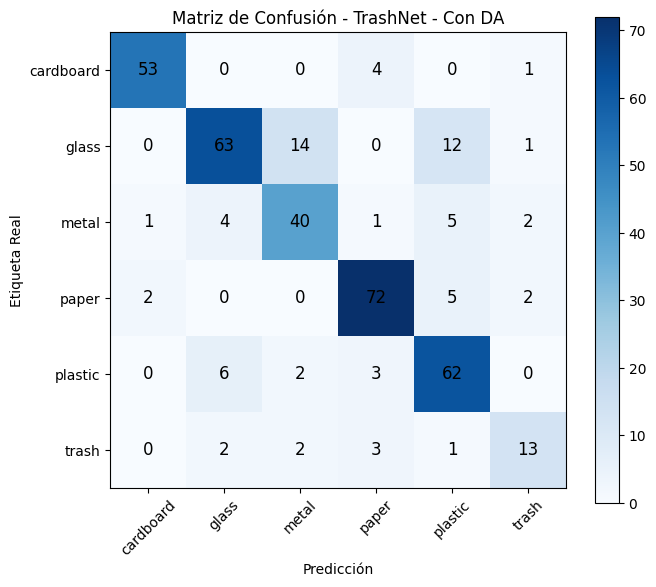

Exactitud global en TEST (TrashNet - Con DA): 0.8059

>> Exactitud TrashNet Sin DA: 0.7637795275590551
>> Exactitud TrashNet Con DA: 0.8058510638297872


In [9]:
# ================================================================
# BLOQUE 8: EVALUACIÓN TRASHNET (CON MATRICES DE CONFUSIÓN)
# ================================================================

print("\n=== EVALUACIÓN TrashNet - SIN DA ===")
acc_tn = evaluar_en_test(
    model_tn,
    test_loader,
    trashnet_full.classes,
    modelo_nombre="TrashNet - Sin DA"
)

print("\n=== EVALUACIÓN TrashNet - CON DA ===")
acc_tn_aug = evaluar_en_test(
    model_tn_aug,
    test_loader_aug,
    trashnet_aug_full.classes,
    modelo_nombre="TrashNet - Con DA"
)

print("\n>> Exactitud TrashNet Sin DA:", acc_tn)
print(">> Exactitud TrashNet Con DA:", acc_tn_aug)

In [11]:
# ================================================================
# BLOQUE 9: TRANSFER LEARNING TrashNet → TACO
# ================================================================

print("\nCargando pesos del modelo preentrenado en TrashNet (con DA)...")

# 1. Cargar modelo base ResNet18
model_taco = models.resnet18(weights="IMAGENET1K_V1")

# 2. Reemplazar capa final con 6 clases (TrashNet) para coincidir con checkpoint
model_taco.fc = nn.Linear(model_taco.fc.in_features, 6)

# 3. Cargar pesos entrenados en TrashNet
checkpoint_path = os.path.join(output_dir, "resnet18_trashnet_aug_pretrain.pth")
model_taco.load_state_dict(torch.load(checkpoint_path))

# 4. Ahora reemplazar capa final con el número correcto de clases para TACO
taco_temp = datasets.ImageFolder(taco_dir)
num_classes_taco = len(taco_temp.classes)
model_taco.fc = nn.Linear(model_taco.fc.in_features, num_classes_taco)

model_taco = model_taco.to(device)

print("Clases TACO:", taco_temp.classes)


Cargando pesos del modelo preentrenado en TrashNet (con DA)...
Clases TACO: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']



Época 1/10
--------------------------------------------------
TRAIN | Loss: 0.8247 | Acc: 0.7256
VAL | Loss: 1.0098 | Acc: 0.6417

Época 2/10
--------------------------------------------------
TRAIN | Loss: 0.3153 | Acc: 0.9130
VAL | Loss: 0.8968 | Acc: 0.6753

Época 3/10
--------------------------------------------------
TRAIN | Loss: 0.1812 | Acc: 0.9477
VAL | Loss: 0.9135 | Acc: 0.6953

Época 4/10
--------------------------------------------------
TRAIN | Loss: 0.1116 | Acc: 0.9676
VAL | Loss: 0.9515 | Acc: 0.6830

Época 5/10
--------------------------------------------------
TRAIN | Loss: 0.0788 | Acc: 0.9814
VAL | Loss: 1.0083 | Acc: 0.6753

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.0646 | Acc: 0.9820
VAL | Loss: 1.0927 | Acc: 0.6708

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.0701 | Acc: 0.9843
VAL | Loss: 1.0364 | Acc: 0.7060

Época 8/10
--------------------------------------------------
TRAIN | Loss: 0.0384

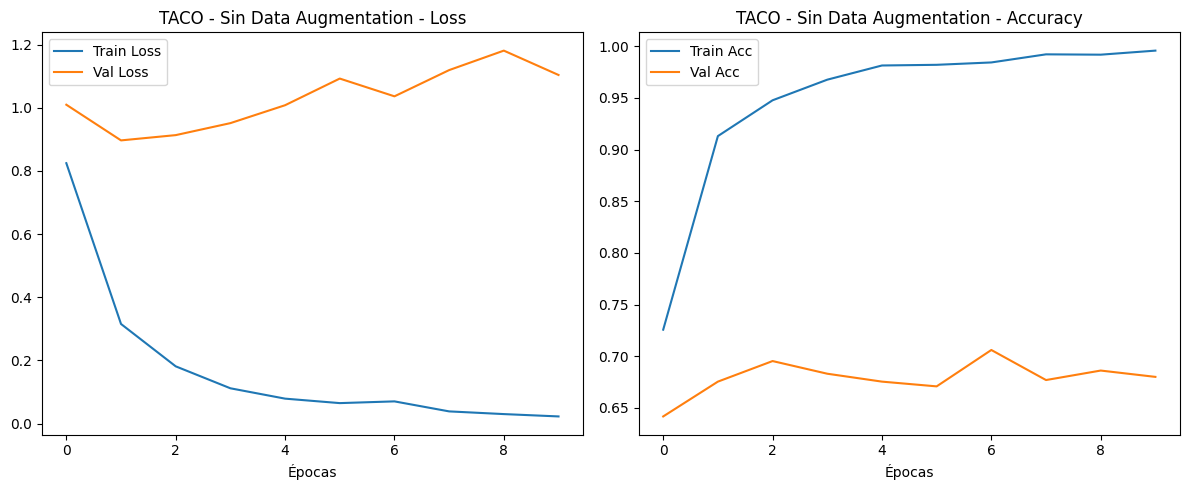

In [12]:
# ================================================================
# BLOQUE 10.1: TACO - SIN DATA AUGMENTATION
# ================================================================

no_transform = transforms.ToTensor()
taco_full = datasets.ImageFolder(taco_dir, transform=no_transform)

train_idx, val_idx, test_idx = split_stratified(taco_full)
train_ds = Subset(taco_full, train_idx)
val_ds   = Subset(taco_full, val_idx)
test_ds  = Subset(taco_full, test_idx)

sampler_taco = make_balanced_sampler(train_ds, taco_full)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler_taco)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

dataloaders_taco = {"train": train_loader, "val": val_loader}
dataset_sizes_taco = {"train": len(train_ds), "val": len(val_ds)}

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_taco.parameters(), lr=1e-4)

model_taco_sinDA, hist_taco_sinDA = train_model(
    model_taco, criterion, optimizer,
    dataloaders_taco, dataset_sizes_taco,
    num_epochs=10, patience=4,
    save_name="resnet18_trashnet_to_taco_sinDA.pth"
)

plot_curves(hist_taco_sinDA, "TACO - Sin Data Augmentation")



Época 1/10
--------------------------------------------------
TRAIN | Loss: 1.0836 | Acc: 0.6031
VAL | Loss: 0.8806 | Acc: 0.6860

Época 2/10
--------------------------------------------------
TRAIN | Loss: 0.4746 | Acc: 0.8517
VAL | Loss: 0.8991 | Acc: 0.6890

Época 3/10
--------------------------------------------------
TRAIN | Loss: 0.1755 | Acc: 0.9611
VAL | Loss: 0.9290 | Acc: 0.6921

Época 4/10
--------------------------------------------------
TRAIN | Loss: 0.0617 | Acc: 0.9895
VAL | Loss: 0.9544 | Acc: 0.7149

Época 5/10
--------------------------------------------------
TRAIN | Loss: 0.0292 | Acc: 0.9977
VAL | Loss: 1.0290 | Acc: 0.7104

Época 6/10
--------------------------------------------------
TRAIN | Loss: 0.0202 | Acc: 0.9987
VAL | Loss: 1.0918 | Acc: 0.6829

Época 7/10
--------------------------------------------------
TRAIN | Loss: 0.0124 | Acc: 0.9990
VAL | Loss: 1.0481 | Acc: 0.7210

Época 8/10
--------------------------------------------------
TRAIN | Loss: 0.0073

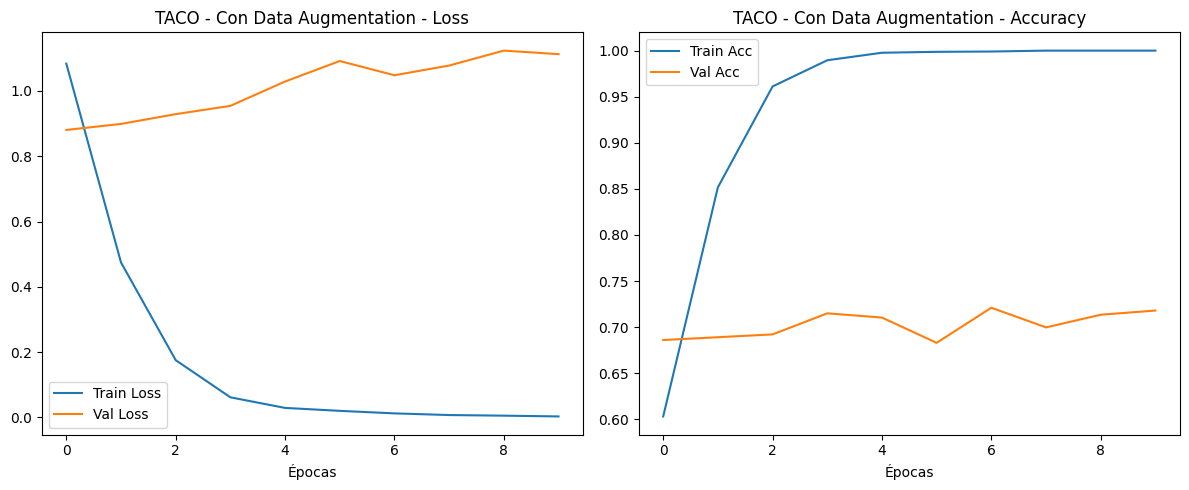

In [14]:
# ================================================================
# BLOQUE 10.2: TACO - CON DATA AUGMENTATION
# ================================================================

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor()
])

base_transform = transforms.ToTensor()

taco_full_aug = datasets.ImageFolder(taco_dir, transform=train_transform)

train_size = int(0.7 * len(taco_full_aug))
val_size   = int(0.15 * len(taco_full_aug))
test_size  = len(taco_full_aug) - train_size - val_size

torch.manual_seed(42)
train_ds_aug, val_ds_aug, test_ds_aug = random_split(
    taco_full_aug, [train_size, val_size, test_size]
)

val_ds_aug.dataset.transform  = base_transform
test_ds_aug.dataset.transform = base_transform

train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True)
val_loader_aug   = DataLoader(val_ds_aug, batch_size=32)
test_loader_aug  = DataLoader(test_ds_aug, batch_size=32)

dataloaders_taco_aug = {"train": train_loader_aug, "val": val_loader_aug}
dataset_sizes_taco_aug = {"train": len(train_ds_aug), "val": len(val_ds_aug)}

# ======================================================
# 1. Crear modelo base
# ======================================================
model_taco_aug = models.resnet18(weights="IMAGENET1K_V1")

# ======================================================
# 2. REEMPLAZAR FC PARA COINCIDIR CON TRASHNET (6 CLASES)
# ======================================================
model_taco_aug.fc = nn.Linear(model_taco_aug.fc.in_features, 6)

# ======================================================
# 3. Cargar pesos del pre-entrenamiento TrashNet
# ======================================================
checkpoint_path = os.path.join(output_dir, "resnet18_trashnet_aug_pretrain.pth")
model_taco_aug.load_state_dict(torch.load(checkpoint_path))

# ======================================================
# 4. Reemplazar FC con el número REAL de clases de TACO
# ======================================================
model_taco_aug.fc = nn.Linear(model_taco_aug.fc.in_features, num_classes_taco)
model_taco_aug = model_taco_aug.to(device)

# Entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_taco_aug.parameters(), lr=1e-4)

model_taco_conDA, hist_taco_conDA = train_model(
    model_taco_aug, criterion, optimizer,
    dataloaders_taco_aug, dataset_sizes_taco_aug,
    num_epochs=10, patience=4,
    save_name="resnet18_trashnet_to_taco_conDA.pth"
)

plot_curves(hist_taco_conDA, "TACO - Con Data Augmentation")


=== TACO - SIN DA ===

   REPORTES DE EVALUACIÓN - TrashNet→TACO - Sin DA

              precision    recall  f1-score   support

   cardboard      0.593     0.444     0.508        36
       glass      0.645     0.526     0.580        38
       metal      0.675     0.684     0.679        79
       paper      0.688     0.324     0.440        34
     plastic      0.766     0.652     0.704       287
       trash      0.600     0.841     0.700       189

    accuracy                          0.674       663
   macro avg      0.661     0.578     0.602       663
weighted avg      0.688     0.674     0.669       663



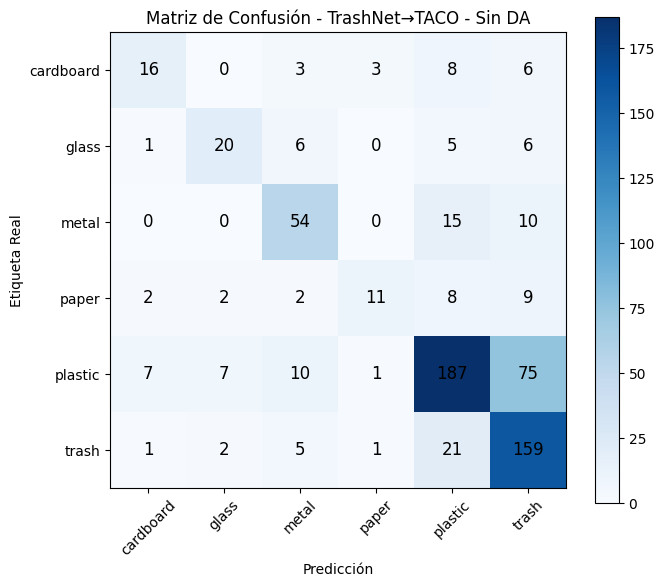

Exactitud global en TEST (TrashNet→TACO - Sin DA): 0.6742

=== TACO - CON DA ===

   REPORTES DE EVALUACIÓN - TrashNet→TACO - Con DA

              precision    recall  f1-score   support

   cardboard      0.553     0.636     0.592        33
       glass      0.750     0.450     0.562        40
       metal      0.675     0.761     0.715        71
       paper      0.222     0.091     0.129        22
     plastic      0.762     0.797     0.780       306
       trash      0.753     0.757     0.755       185

    accuracy                          0.729       657
   macro avg      0.619     0.582     0.589       657
weighted avg      0.721     0.729     0.721       657



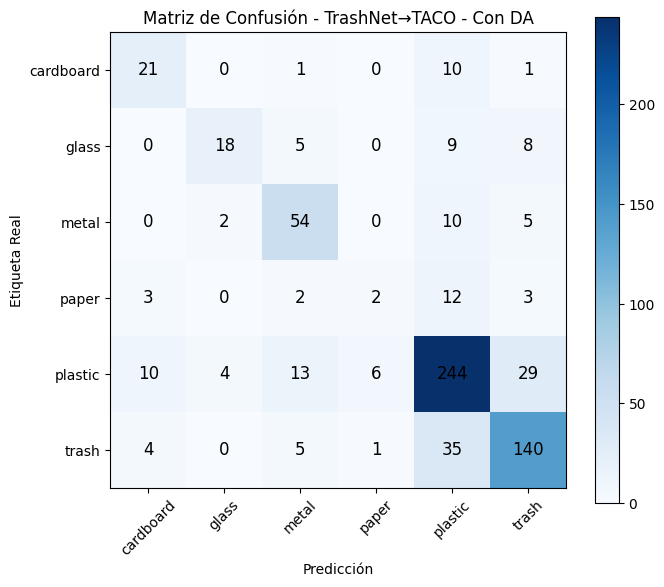

Exactitud global en TEST (TrashNet→TACO - Con DA): 0.7291

>> Exactitud TACO Sin DA: 0.6742081447963801
>> Exactitud TACO Con DA: 0.7290715372907154


In [15]:
# ================================================================
# BLOQUE 11: EVALUACIÓN FINAL TACO (CON MATRICES DE CONFUSIÓN)
# ================================================================

print("\n=== TACO - SIN DA ===")
acc_taco_sinDA = evaluar_en_test(
    model_taco_sinDA,
    test_loader,
    taco_full.classes,
    modelo_nombre="TrashNet→TACO - Sin DA"
)

print("\n=== TACO - CON DA ===")
acc_taco_conDA = evaluar_en_test(
    model_taco_conDA,
    test_loader_aug,
    taco_full_aug.classes,
    modelo_nombre="TrashNet→TACO - Con DA"
)

print("\n>> Exactitud TACO Sin DA:", acc_taco_sinDA)
print(">> Exactitud TACO Con DA:", acc_taco_conDA)